In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
jiji = pd.read_csv("jiji_car_daataset.csv")

In [3]:
jiji.head()

,title,make,model,year,condition,transmission,price
0,Toyota RAV4 2007 Black,Toyota,RAV4,2007.0,foreign used,manual,"₦ 8,500,000"
1,Toyota Camry LE 4dr Sedan (2.4L 4cyl 5M) 2003 ...,Toyota,Camry LE,2003.0,local used,automatic,"₦ 4,000,000"
2,Hyundai Sonata 2019 Black,Hyundai,Sonata,2019.0,foreign used,automatic,"₦ 29,109,375"
3,Mercedes-Benz GLK-Class 350 4MATIC 2010 Black,Mercedes-Benz,GLK-Class 350,2010.0,foreign used,automatic,"₦ 17,500,000"
4,Lexus RX 330 2005 Blue,Lexus,RX 330,2005.0,foreign used,automatic,"₦ 12,600,000"


In [4]:
jiji.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1998 non-null   object 
 1   make          1991 non-null   object 
 2   model         1991 non-null   object 
 3   year          1991 non-null   float64
 4   condition     1998 non-null   object 
 5   transmission  1994 non-null   object 
 6   price         1998 non-null   object 
dtypes: float64(1), object(6)
memory usage: 109.4+ KB


In [5]:
jiji.isnull().sum()

title           0
make            7
model           7
year            7
condition       0
transmission    4
price           0
dtype: int64

In [6]:
jiji = jiji.dropna()
jiji.isnull().sum()

title           0
make            0
model           0
year            0
condition       0
transmission    0
price           0
dtype: int64

In [7]:
jiji.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1987 entries, 0 to 1997
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1987 non-null   object 
 1   make          1987 non-null   object 
 2   model         1987 non-null   object 
 3   year          1987 non-null   float64
 4   condition     1987 non-null   object 
 5   transmission  1987 non-null   object 
 6   price         1987 non-null   object 
dtypes: float64(1), object(6)
memory usage: 124.2+ KB


In [8]:
jiji['price'] = (
    jiji['price']
    .astype(str)
    .str.replace("₦", "", regex=False)
    .str.replace(",", "", regex=False)
)

jiji['price'] = pd.to_numeric(jiji['price'], errors='coerce')
jiji.head()

,title,make,model,year,condition,transmission,price
0,Toyota RAV4 2007 Black,Toyota,RAV4,2007.0,foreign used,manual,8500000
1,Toyota Camry LE 4dr Sedan (2.4L 4cyl 5M) 2003 ...,Toyota,Camry LE,2003.0,local used,automatic,4000000
2,Hyundai Sonata 2019 Black,Hyundai,Sonata,2019.0,foreign used,automatic,29109375
3,Mercedes-Benz GLK-Class 350 4MATIC 2010 Black,Mercedes-Benz,GLK-Class 350,2010.0,foreign used,automatic,17500000
4,Lexus RX 330 2005 Blue,Lexus,RX 330,2005.0,foreign used,automatic,12600000


In [9]:
Q1 = jiji['price'].quantile(0.25)
Q3 = jiji['price'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

jiji=jiji[(jiji['price'] >= lower_bound) & (jiji['price'] <= upper_bound)]
jiji.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1790 entries, 0 to 1996
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1790 non-null   object 
 1   make          1790 non-null   object 
 2   model         1790 non-null   object 
 3   year          1790 non-null   float64
 4   condition     1790 non-null   object 
 5   transmission  1790 non-null   object 
 6   price         1790 non-null   int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 111.9+ KB


In [10]:
jiji['make'] = jiji['make'].astype(str).str.title().str.strip().str.replace("-", " ")

In [11]:
jiji['condition'] = jiji['condition'].astype(str).str.title().str.strip().str.replace("-", "")

In [12]:
jiji['transmission'] = jiji['transmission'].astype(str).str.title().str.strip().str.replace("-", "")

In [13]:
jiji['model'] = jiji['model'].astype(str).str.title().str.strip().str.replace("-", "")
jiji.head(10)

,title,make,model,year,condition,transmission,price
0,Toyota RAV4 2007 Black,Toyota,Rav4,2007.0,Foreign Used,Manual,8500000
1,Toyota Camry LE 4dr Sedan (2.4L 4cyl 5M) 2003 ...,Toyota,Camry Le,2003.0,Local Used,Automatic,4000000
2,Hyundai Sonata 2019 Black,Hyundai,Sonata,2019.0,Foreign Used,Automatic,29109375
3,Mercedes-Benz GLK-Class 350 4MATIC 2010 Black,Mercedes Benz,GlkClass 350,2010.0,Foreign Used,Automatic,17500000
4,Lexus RX 330 2005 Blue,Lexus,Rx 330,2005.0,Foreign Used,Automatic,12600000
5,Honda Accord 2014 Gray,Honda,Accord,2014.0,Local Used,Automatic,8000000
6,Hyundai Sonata 2012 White,Hyundai,Sonata,2012.0,Foreign Used,Automatic,9100000
7,Hyundai Sonata 2012 Burgundy,Hyundai,Sonata,2012.0,Local Used,Automatic,6999999
8,Renault Duster 2013 Blue,Renault,Duster,2013.0,Foreign Used,Automatic,4500000
9,Mercedes-Benz C300 Sport 4Matic Sedan AWD (2.0...,Mercedes Benz,C300 Sport,2016.0,Local Used,Automatic,17500000


In [34]:
jiji['year'].unique()

array([2007., 2003., 2019., 2010., 2005., 2014., 2012., 2013., 2016.,
       2011., 2008., 2015., 2020., 2004., 2018., 2017., 2006., 2002.,
       2001., 2000., 2021., 2023., 2009., 2024., 1994., 2022., 1999.,
       2025., 1997., 1998., 1990., 2026., 1995.])

In [36]:
jiji[jiji['make'] == "New"]

,title,make,model,year,condition,transmission,price
1081,New Omoda C5 2025 Gray,New,Omoda C5,2025.0,Brand New,Automatic,27500000
1550,New Acura ADX AWD w/A-Spec and Advance Package...,New,Acura Adx,2025.0,Brand New,Automatic,45000000
1781,New BYD Sealion 7 EV 2025 Gray,New,Byd Sealion,2025.0,Brand New,Automatic,47800000


In [15]:
most_make_car = jiji['make'].mode()[0]
print(most_make_car)

Toyota


In [16]:
brand_count = jiji['make'].value_counts()
print(brand_count)

make
Toyota           754
Lexus            297
Mercedes Benz    216
Honda            160
Hyundai          104
Acura             63
Ford              40
Nissan            32
Kia               18
Mazda             10
Bmw               10
Land              10
Pontiac            9
Peugeot            8
Audi               8
Volkswagen         8
Mitsubishi         7
Dodge              5
Opel               5
Chevrolet          4
New                3
Jeep               3
Mini               3
Infiniti           3
Volvo              2
Gmc                2
Porsche            2
Subaru             1
Renault            1
Chrysler           1
Genesis            1
Name: count, dtype: int64


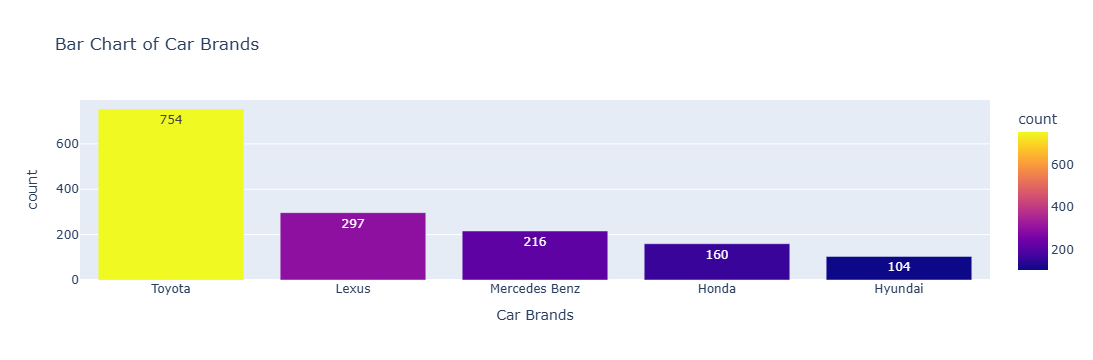

In [17]:
brand_count = jiji['make'].value_counts().reset_index().head(5)
brand_count_columns=('make', 'count')
fig = px.bar(
    brand_count,
    title=('Bar Chart of Car Brands'),
    x='make',
    y='count',
    color='count',
    labels={'Count': 'Count of Car brands', 'make': 'Car Brands'},
    text='count'
    
)
fig.show()

In [18]:
most_common_model_by_brand = jiji.groupby('make')['model'].agg(lambda x: x.value_counts().idxmax())
print(most_common_model_by_brand)

make
Acura                      Zdx Base
Audi                          Q7 55
Bmw                              X3
Chevrolet                    Aveo 1
Chrysler                       Town
Dodge                    Charger Se
Ford                       Explorer
Genesis                       G80 3
Gmc                         Terrain
Honda                        Accord
Hyundai                    Santa Fe
Infiniti                       Qx60
Jeep             Wrangler Unlimited
Kia                             Rio
Land                    Rover Range
Lexus                        Rx 350
Mazda                           Cx9
Mercedes Benz               M Class
Mini                Countryman John
Mitsubishi                  Montero
New                        Omoda C5
Nissan                       XTrail
Opel                         Zafira
Peugeot                         206
Pontiac                        Vibe
Porsche                 Macan Turbo
Renault                      Duster
Subaru                 

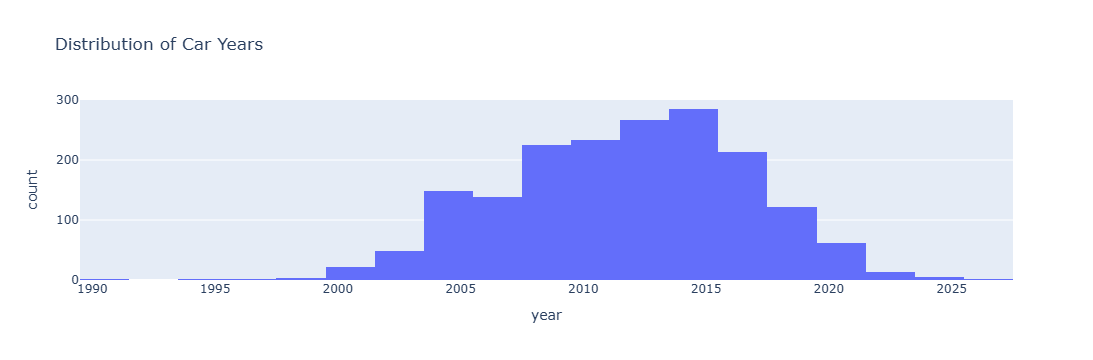

In [19]:
fig = px.histogram(
    jiji,
    x='year',
    nbins=20,
    title='Distribution of Car Years'
)
fig.show()

In [20]:
make_avg_price = jiji.groupby('make')['price'].mean().sort_values(ascending=False)

print(make_avg_price.apply(lambda x: f"{x:,.0f}"))

make
New              40,100,000
Porsche          30,450,000
Genesis          29,850,000
Jeep             26,666,667
Land             26,245,000
Mercedes Benz    23,802,880
Audi             23,206,250
Gmc              21,975,000
Mini             21,500,000
Lexus            21,038,315
Infiniti         20,833,333
Ford             19,346,250
Bmw              17,640,000
Toyota           16,996,713
Volkswagen       16,181,250
Hyundai          15,832,734
Acura            14,772,698
Dodge            14,200,000
Mitsubishi       13,965,714
Honda            12,315,559
Mazda            11,960,000
Kia              10,991,667
Nissan           10,854,688
Volvo            10,500,000
Chevrolet        10,462,500
Pontiac           7,764,956
Opel              6,320,000
Chrysler          5,850,000
Subaru            5,500,000
Peugeot           4,868,750
Renault           4,500,000
Name: price, dtype: object


In [21]:
brand_median_price = jiji.groupby('make')['price'].agg(['mean','median']).sort_values('mean', ascending=False)

print(brand_median_price.map(lambda x: f"{x:,.0f}"))

                     mean      median
make                                 
New            40,100,000  45,000,000
Porsche        30,450,000  30,450,000
Genesis        29,850,000  29,850,000
Jeep           26,666,667  27,500,000
Land           26,245,000  26,000,000
Mercedes Benz  23,802,880  22,500,000
Audi           23,206,250  14,950,000
Gmc            21,975,000  21,975,000
Mini           21,500,000  18,000,000
Lexus          21,038,315  19,000,000
Infiniti       20,833,333  19,500,000
Ford           19,346,250  17,250,000
Bmw            17,640,000  15,250,000
Toyota         16,996,713  14,050,000
Volkswagen     16,181,250  12,700,000
Hyundai        15,832,734  14,925,000
Acura          14,772,698  12,680,000
Dodge          14,200,000  10,500,000
Mitsubishi     13,965,714  16,000,000
Honda          12,315,559  11,650,000
Mazda          11,960,000  10,050,000
Kia            10,991,667   8,000,000
Nissan         10,854,688  10,050,000
Volvo          10,500,000  10,500,000
Chevrolet   

In [22]:
model_avg_price = jiji.groupby('model')['price'].agg(['mean','median']).sort_values('mean', ascending=False)

print(model_avg_price.map(lambda x:f"{x:,.0f}"))

                       mean      median
model                                  
C43              55,000,000  55,000,000
Mustang          51,000,000  51,000,000
GlsClass         49,500,000  49,500,000
F150 Xl          49,000,000  49,000,000
GlClass 450      49,000,000  49,000,000
...                     ...         ...
Prius Hybrid      2,500,000   2,500,000
307 1             2,400,000   2,400,000
XTrail 2          2,100,000   2,100,000
Accord Aerodeck   1,999,999   1,999,999
Spacestar         1,850,000   1,850,000

[391 rows x 2 columns]


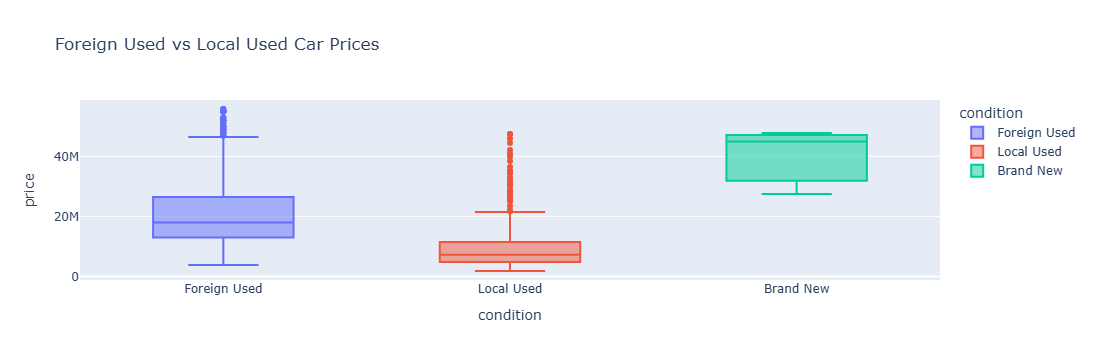

In [23]:
fig = px.box(
    jiji,
    x="condition",
    y="price",
    color="condition",
    title="Foreign Used vs Local Used Car Prices"
)

fig.show()

In [24]:
avg_condition_price = jiji.groupby("condition")["price"].agg(["mean","median"])
print(avg_condition_price.map(lambda x:f"{x:,.0f}"))

                    mean      median
condition                           
Brand New     40,100,000  45,000,000
Foreign Used  20,941,328  18,000,000
Local Used     9,782,373   7,200,000


In [25]:
avg_transmission_price = jiji.groupby('transmission')['price'].agg(['mean','median'])
print(avg_transmission_price.map(lambda x:f"{x:,.0f}"))

                    mean      median
transmission                        
Automatic     17,979,101  15,000,000
Manual         9,183,636   6,500,000


In [26]:
common_transmission = jiji['transmission'].value_counts()
print(common_transmission)

transmission
Automatic    1746
Manual         44
Name: count, dtype: int64


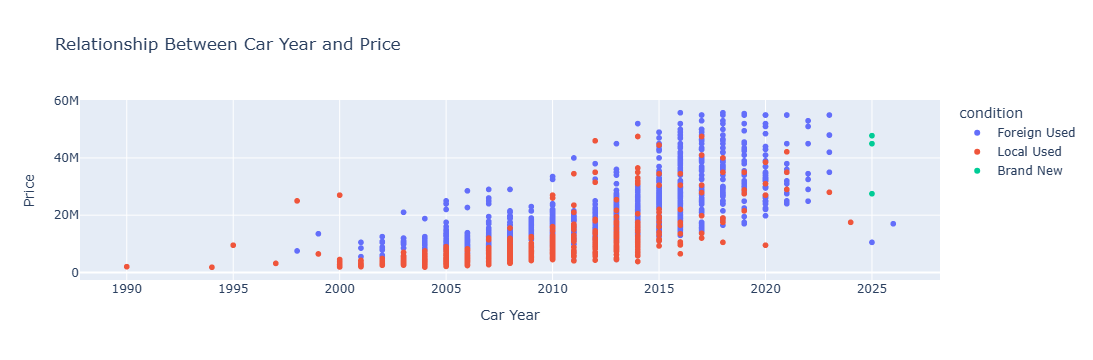

In [27]:
fig = px.scatter(
    jiji,
    x="year",
    y="price",
    color="condition",
    title="Relationship Between Car Year and Price",
    labels={"year": "Car Year", "price": "Price"}
)

fig.show()

In [28]:
correlation = jiji['year'].corr(jiji['price'])

print(f"Correlation between year and price: {correlation:.2f}")

Correlation between year and price: 0.72


In [29]:
best_product = jiji.groupby(['make','model'])['price'].sum().sort_values(ascending=False)

best_product.apply(lambda x: f"{x:,}").head(10)

make           model             
Lexus          Rx 350                2,745,709,999
               Es 350                1,193,430,000
Toyota         Highlander Limited    1,098,230,000
Mercedes Benz  M Class                 950,819,999
               GleClass Gle            762,230,000
Toyota         Camry                   754,609,999
               Highlander              748,676,561
               Highlander Xle          681,999,999
Mercedes Benz  GlcClass                666,500,000
Lexus          Gx 460                  624,300,000
Name: price, dtype: object

In [30]:
most_revenue_by_condition = jiji.groupby('condition')['price'].sum().sort_values(ascending=False)

most_revenue_by_condition.apply(lambda x: f"{x:,}")

condition
Foreign Used    26,637,369,294
Local Used       5,037,921,903
Brand New          120,300,000
Name: price, dtype: object

In [31]:
cars_per_year =jiji['year'].value_counts().sort_index()

cars_per_year = jiji['year'].value_counts()

top_year = cars_per_year.idxmax()
top_count = cars_per_year.max()

print(f"Year with the highest number of cars: {top_year} ({top_count:,} cars)")

Year with the highest number of cars: 2013.0 (157 cars)


In [33]:
jiji.to_csv("jiji_cleaned_car_dataset", index=False)

1. The brand that dominates the higher price range is the new brand of cars. Lexus, Toyota, and Mercedes-Benz appear among the 15 top-priced cars. Also, they are the most sought-after cars in the Nigerian car market.
2. The correlation between year and price has a strong positive relationship of 0.72. Which indicates that as the year goes by the price of cars goes up.
3. Foreign used cars have a mean price of about 18  million as against local used cars, which has an average of about 8 million. This indicates that foreign used cars cost more than local used cars. This variation as appears in car year as foreign used cars are more expensive than local used cars year in year out.
4. Automatic cars are common in the Nigerian car market and they cost more than the manual cars with an average price of 17 million as compared with 9 million.
5. The Lexus Rx 350 performs best overall recording the highest car price.
6. Foreign used cars contributes more revenue as it records the highest. This shows that generally foreign used car are in more demand in the nigerian car market.
7. The year that records the highest number of cars is 2013 with 157 cars listed. Out of this 157 cars listed in 2013, about 78% of the cars are foreign used. This shows the popularity of demand for foreign used cars in the nigeria car market.